#1. Load the given dataset and identify missing values in numerical columns, then replace them using mean imputation and display the dataset before and after preprocessing.

In [11]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/sample_data/california_housing_test.csv")

# Display dataset before preprocessing
print("Dataset BEFORE preprocessing:\n")
print(df.head())

# Check missing values
print("\nMissing values before:\n")
print(df.isnull().sum())

Dataset BEFORE preprocessing:

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  

Missing values before:

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms     

Identify Numerical Columns

In [12]:
# Select numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:", num_cols)


Numerical Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


Apply Mean Imputation

In [13]:
# Fill missing values with mean
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3751/2614114207.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Display Dataset Before Preprocessing

In [14]:
print("\nDataset AFTER preprocessing:\n")
print(df.head())

# Check missing values again
print("\nMissing values after:\n")
print(df.isnull().sum())


Dataset AFTER preprocessing:

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  

Missing values after:

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms      

# 2.Using the given dataset, identify missing values in categorical columns and replace them using mode, then compare frequency distribution before and after

In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Admission_Prediction.csv")

# Display missing values
print("Missing values BEFORE:\n")
print(df.isnull().sum())

Missing values BEFORE:

Serial No.            0
GRE Score            15
TOEFL Score          10
University Rating    15
SOP                   0
LOR                   0
CGPA                  0
Research              0
Chance of Admit       0
dtype: int64


Identify Categorical Columns

In [16]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:", cat_cols)


Categorical Columns: Index([], dtype='object')


Frequency Distribution BEFORE Imputation

In [17]:
print("\nFrequency BEFORE imputation:\n")
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Frequency BEFORE imputation:



Replace Missing Values using Mode

In [19]:
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

Frequency Distribution After Imputation

In [20]:
print("\nFrequency AFTER imputation:\n")
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Frequency AFTER imputation:



Verify Missing Values Removed

In [21]:
print("\nMissing values AFTER:\n")
print(df.isnull().sum())


Missing values AFTER:

Serial No.            0
GRE Score            15
TOEFL Score          10
University Rating    15
SOP                   0
LOR                   0
CGPA                  0
Research              0
Chance of Admit       0
dtype: int64


# 3.Using the given dataset, apply Label Encoding on a categorical column and display the transformed values

In [30]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("/content/sample_label_encoding.csv")

print("Original Data:\n")
print(df.head())

Original Data:

   id   name  gender    city
0   1   Amit    Male    Pune
1   2   Neha  Female  Mumbai
2   3  Rahul    Male   Delhi
3   4  Priya  Female    Pune
4   5  Karan    Male  Mumbai


Select a Categorical Column

In [31]:
# Example categorical column (change as per your dataset)
col = 'gender'   # e.g., Male/Female

Apply Label Encoding

In [32]:
le = LabelEncoder()

df[col] = le.fit_transform(df[col])

Display Transformed Values

In [33]:
print("\nAfter Label Encoding:\n")
print(df[[col]].head())


After Label Encoding:

   gender
0       1
1       0
2       1
3       0
4       1


Show Mapping

In [34]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel Mapping:", mapping)


Label Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


# 4.Using the given dataset, apply One-Hot Encoding on categorical features and show the increase in number of columns.

In [35]:
import pandas as pd

df = pd.read_csv("/content/sample_label_encoding.csv")

print("Original Dataset:\n")
print(df.head())

Original Dataset:

   id   name  gender    city
0   1   Amit    Male    Pune
1   2   Neha  Female  Mumbai
2   3  Rahul    Male   Delhi
3   4  Priya  Female    Pune
4   5  Karan    Male  Mumbai


Check Number of Columns Before Encoding

In [36]:
print("\nNumber of columns BEFORE encoding:", df.shape[1])


Number of columns BEFORE encoding: 4


Apply One-Hot Encoding

In [37]:
# Apply One-Hot Encoding on categorical columns
df_encoded = pd.get_dummies(df, columns=['gender', 'city'])

print("\nDataset AFTER One-Hot Encoding:\n")
print(df_encoded.head())


Dataset AFTER One-Hot Encoding:

   id   name  gender_Female  gender_Male  city_Delhi  city_Mumbai  city_Pune
0   1   Amit          False         True       False        False       True
1   2   Neha           True        False       False         True      False
2   3  Rahul          False         True        True        False      False
3   4  Priya           True        False       False        False       True
4   5  Karan          False         True       False         True      False


Check Number of Columns After Encoding

In [38]:
print("\nNumber of columns AFTER encoding:", df_encoded.shape[1])


Number of columns AFTER encoding: 7


Show Increase in Columns

In [39]:
increase = df_encoded.shape[1] - df.shape[1]
print("\nIncrease in number of columns:", increase)


Increase in number of columns: 3


# 5.Using the given dataset, perform Min-Max scaling on numerical features and verify that all values lie between 0 and 1.

In [40]:
import pandas as pd

df = pd.read_csv("/content/Admission_Prediction.csv")

print("Original Dataset:\n")
print(df.head())

Original Dataset:

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1      337.0        118.0                4.0  4.5  4.5  9.65   
1           2      324.0        107.0                4.0  4.0  4.5  8.87   
2           3        NaN        104.0                3.0  3.0  3.5  8.00   
3           4      322.0        110.0                3.0  3.5  2.5  8.67   
4           5      314.0        103.0                2.0  2.0  3.0  8.21   

   Research  Chance of Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  


Select Numerical Columns

In [41]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:", num_cols)


Numerical Columns: Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')


Apply Min-Max Scaling

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

Verify Values are Between 0 and 1

In [43]:
print("\nAfter Scaling:\n")
print(df[num_cols].head())

print("\nMin values:\n", df[num_cols].min())
print("\nMax values:\n", df[num_cols].max())


After Scaling:

   Serial No.  GRE Score  TOEFL Score  University Rating    SOP    LOR  \
0    0.000000       0.94     0.928571               0.75  0.875  0.875   
1    0.002004       0.68     0.535714               0.75  0.750  0.875   
2    0.004008        NaN     0.428571               0.50  0.500  0.625   
3    0.006012       0.64     0.642857               0.50  0.625  0.375   
4    0.008016       0.48     0.392857               0.25  0.250  0.500   

       CGPA  Research  Chance of Admit  
0  0.913462       1.0         0.920635  
1  0.663462       1.0         0.666667  
2  0.384615       1.0         0.603175  
3  0.599359       1.0         0.730159  
4  0.451923       0.0         0.492063  

Min values:
 Serial No.           0.0
GRE Score            0.0
TOEFL Score          0.0
University Rating    0.0
SOP                  0.0
LOR                  0.0
CGPA                 0.0
Research             0.0
Chance of Admit      0.0
dtype: float64

Max values:
 Serial No.           1.0

# 6.Using the given dataset, apply StandardScaler and verify mean is approximately 0 and standard deviation is 1.

In [44]:
import pandas as pd

df = pd.read_csv("/content/Admission_Prediction.csv")

print("Original Dataset:\n")
print(df.head())

Original Dataset:

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1      337.0        118.0                4.0  4.5  4.5  9.65   
1           2      324.0        107.0                4.0  4.0  4.5  8.87   
2           3        NaN        104.0                3.0  3.0  3.5  8.00   
3           4      322.0        110.0                3.0  3.5  2.5  8.67   
4           5      314.0        103.0                2.0  2.0  3.0  8.21   

   Research  Chance of Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  


Select Numerical Columns

In [45]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:", num_cols)


Numerical Columns: Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')


Apply StandardScaler

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[num_cols])

# Convert back to DataFrame for better understanding
scaled_df = pd.DataFrame(scaled_data, columns=num_cols)

print("\nScaled Data:\n")
print(scaled_df.head())


Scaled Data:

   Serial No.  GRE Score  TOEFL Score  University Rating       SOP       LOR  \
0   -1.728590   1.814890     1.770566           0.767133  1.137360  1.098944   
1   -1.721662   0.660675    -0.030746           0.767133  0.632315  1.098944   
2   -1.714734        NaN    -0.522013          -0.106246 -0.377773  0.017306   
3   -1.707806   0.483104     0.460521          -0.106246  0.127271 -1.064332   
4   -1.700877  -0.227182    -0.685769          -0.979625 -1.387862 -0.523513   

       CGPA  Research  Chance of Admit  
0  1.776806  0.886405         1.406107  
1  0.485859  0.886405         0.271349  
2 -0.954043  0.886405        -0.012340  
3  0.154847  0.886405         0.555039  
4 -0.606480 -1.128152        -0.508797  


Verify Mean and Standard Deviation

In [47]:
print("\nMean of scaled data:\n", scaled_df.mean())
print("\nStandard Deviation of scaled data:\n", scaled_df.std())


Mean of scaled data:
 Serial No.           1.136868e-16
GRE Score           -7.544938e-16
TOEFL Score          9.280558e-16
University Rating    7.325183e-18
SOP                 -8.526513e-17
LOR                  4.263256e-17
CGPA                 3.119283e-15
Research            -7.815970e-17
Chance of Admit     -3.304024e-16
dtype: float64

Standard Deviation of scaled data:
 Serial No.           1.001002
GRE Score            1.001033
TOEFL Score          1.001022
University Rating    1.001033
SOP                  1.001002
LOR                  1.001002
CGPA                 1.001002
Research             1.001002
Chance of Admit      1.001002
dtype: float64


# 7.Using the given dataset, create a new feature using existing columns and display the updated dataset.

In [50]:
import pandas as pd

df = pd.read_csv("/content/feature_engineering_dataset.csv")

print("Original Dataset:\n")
print(df.head())

Original Dataset:

   id  age  fare  math_marks  science_marks
0   1   22   100          70             68
1   2   30   200          80             78
2   3   25   150          65             70
3   4   40   300          90             88
4   5   35   250          85             82


Create a New Feature

In [56]:
df['total_marks'] = df['math_marks'] + df['science_marks']
df['fare_per_age'] = df['fare'] / (df['age'] + 1)

Display Updated Dataset

In [55]:
print("\nUpdated Dataset:\n")
print(df.head())


Updated Dataset:

   id  age  fare  math_marks  science_marks  total_marks  fare_per_age
0   1   22   100          70             68          138      4.347826
1   2   30   200          80             78          158      6.451613
2   3   25   150          65             70          135      5.769231
3   4   40   300          90             88          178      7.317073
4   5   35   250          85             82          167      6.944444


# 8.Using the given dataset, display summary statistics including mean, median, minimum, maximum, and standard deviation.

In [57]:
import pandas as pd

df = pd.read_csv("/content/feature_engineering_dataset.csv")

print("Dataset:\n")
print(df.head())

Dataset:

   id  age  fare  math_marks  science_marks
0   1   22   100          70             68
1   2   30   200          80             78
2   3   25   150          65             70
3   4   40   300          90             88
4   5   35   250          85             82


Display Summary Statistics (All at once)

In [58]:
print("\nSummary Statistics:\n")
print(df.describe())


Summary Statistics:

            id        age        fare  math_marks  science_marks
count  8.00000   8.000000    8.000000    8.000000       8.000000
mean   4.50000  34.375000  241.250000   80.625000      80.625000
std    2.44949   9.927415  103.016989    9.855202       9.811618
min    1.00000  22.000000  100.000000   65.000000      68.000000
25%    2.75000  27.250000  172.500000   73.750000      73.000000
50%    4.50000  32.500000  225.000000   82.500000      80.000000
75%    6.25000  41.250000  312.500000   88.500000      88.500000
max    8.00000  50.000000  400.000000   92.000000      95.000000


Display Mean, Median, Min, Max, Std Separately

In [59]:
print("\nMean:\n", df.mean(numeric_only=True))

print("\nMedian:\n", df.median(numeric_only=True))

print("\nMinimum:\n", df.min(numeric_only=True))

print("\nMaximum:\n", df.max(numeric_only=True))

print("\nStandard Deviation:\n", df.std(numeric_only=True))


Mean:
 id                 4.500
age               34.375
fare             241.250
math_marks        80.625
science_marks     80.625
dtype: float64

Median:
 id                 4.5
age               32.5
fare             225.0
math_marks        82.5
science_marks     80.0
dtype: float64

Minimum:
 id                 1
age               22
fare             100
math_marks        65
science_marks     68
dtype: int64

Maximum:
 id                 8
age               50
fare             400
math_marks        92
science_marks     95
dtype: int64

Standard Deviation:
 id                 2.449490
age                9.927415
fare             103.016989
math_marks         9.855202
science_marks      9.811618
dtype: float64


# 9.Using the given dataset, plot histograms for numerical features and describe the distribution.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/feature_engineering_dataset.csv")

print(df.head())

   id  age  fare  math_marks  science_marks
0   1   22   100          70             68
1   2   30   200          80             78
2   3   25   150          65             70
3   4   40   300          90             88
4   5   35   250          85             82


Select Numerical Columns

In [61]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical Columns:", num_cols)

Numerical Columns: Index(['id', 'age', 'fare', 'math_marks', 'science_marks'], dtype='object')


Plot Histogram

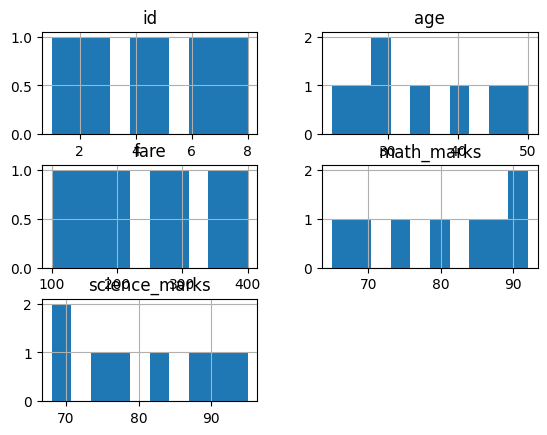

In [62]:
df[num_cols].hist()
plt.show()

# 10.Using the given dataset, draw boxplots for selected features and identify outliers.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/feature_engineering_dataset.csv")

print(df.head())

   id  age  fare  math_marks  science_marks
0   1   22   100          70             68
1   2   30   200          80             78
2   3   25   150          65             70
3   4   40   300          90             88
4   5   35   250          85             82


Select Numerical Features

In [64]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical Columns:", num_cols)

Numerical Columns: Index(['id', 'age', 'fare', 'math_marks', 'science_marks'], dtype='object')


Draw Boxplots

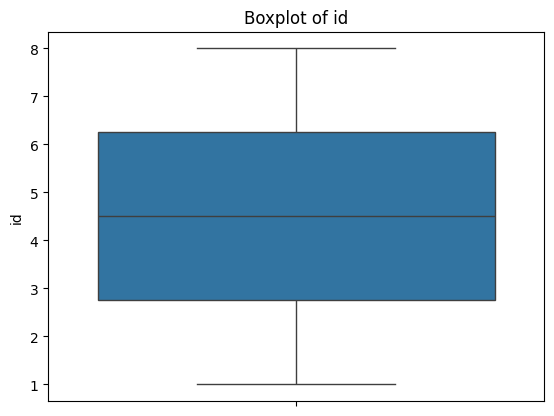

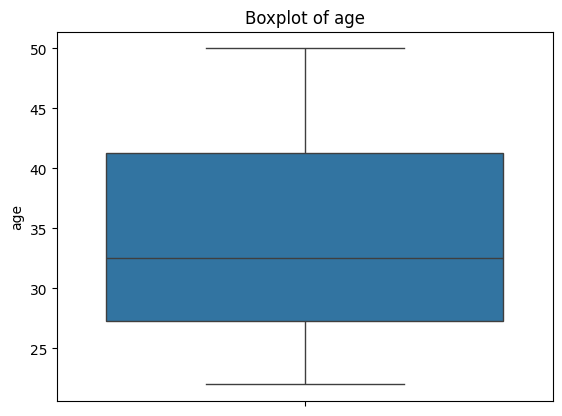

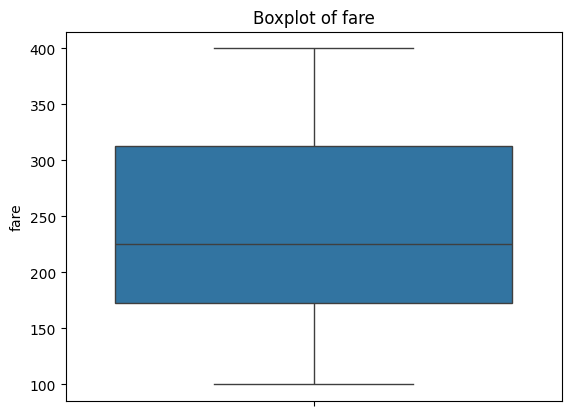

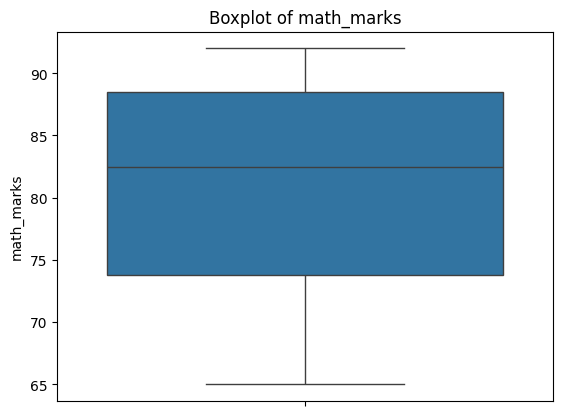

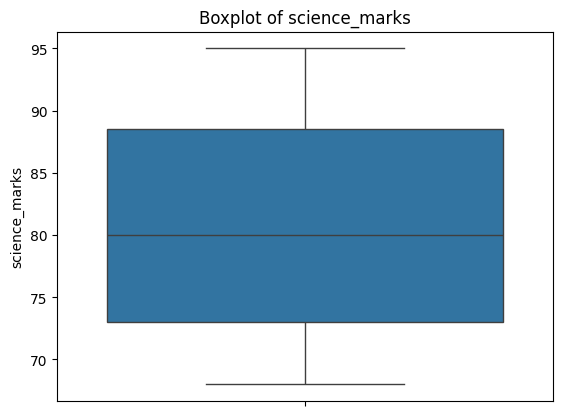

In [65]:
for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# 11.Using the given dataset, compute the correlation matrix and identify highly correlated features.

In [66]:
import pandas as pd

df = pd.read_csv("/content/feature_engineering_dataset.csv")

print(df.head())

   id  age  fare  math_marks  science_marks
0   1   22   100          70             68
1   2   30   200          80             78
2   3   25   150          65             70
3   4   40   300          90             88
4   5   35   250          85             82


Select Numerical Columns

In [67]:
import numpy as np

num_df = df.select_dtypes(include=[np.number])

Compute Correlation Matrix

In [68]:
corr_matrix = num_df.corr()

print("\nCorrelation Matrix:\n")
print(corr_matrix)


Correlation Matrix:

                     id       age      fare  math_marks  science_marks
id             1.000000  0.778406  0.789754    0.648000       0.757872
age            0.778406  1.000000  0.998240    0.887959       0.954969
fare           0.789754  0.998240  1.000000    0.885599       0.955961
math_marks     0.648000  0.887959  0.885599    1.000000       0.955688
science_marks  0.757872  0.954969  0.955961    0.955688       1.000000


Identify Highly Correlated Features

In [69]:
# Set threshold (commonly 0.7 or 0.8)
threshold = 0.7

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr.append((col1, col2, corr_matrix.iloc[i, j]))

print("\nHighly Correlated Features (>|0.7|):\n")
for pair in high_corr:
    print(pair)


Highly Correlated Features (>|0.7|):

('age', 'id', np.float64(0.7784057395653157))
('fare', 'id', np.float64(0.789753739140458))
('fare', 'age', np.float64(0.9982403718250548))
('math_marks', 'age', np.float64(0.88795941859812))
('math_marks', 'fare', np.float64(0.8855989243026828))
('science_marks', 'id', np.float64(0.7578720087953885))
('science_marks', 'age', np.float64(0.9549694851824935))
('science_marks', 'fare', np.float64(0.9559606214161206))
('science_marks', 'math_marks', np.float64(0.9556880570799837))


# 12.Using the given dataset, plot a heatmap for correlation matrix and interpret relationships.

In [70]:
import pandas as pd

df = pd.read_csv("/content/sample_label_encoding.csv")

print(df.head())

   id   name  gender    city
0   1   Amit    Male    Pune
1   2   Neha  Female  Mumbai
2   3  Rahul    Male   Delhi
3   4  Priya  Female    Pune
4   5  Karan    Male  Mumbai


Select Numerical Columns

In [71]:
import numpy as np

num_df = df.select_dtypes(include=[np.number])

Compute Correlation Matrix

In [72]:
corr_matrix = num_df.corr()

Plot Heatmap

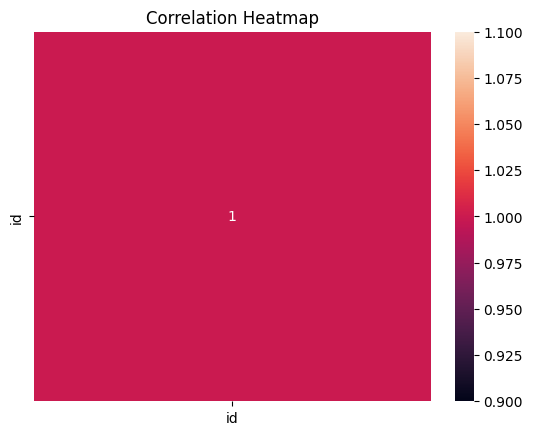

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 13.Using the given dataset, generate a pairplot and analyze relationships between variables.

In [74]:
import pandas as pd

df = pd.read_csv("/content/Admission_Prediction.csv")

print(df.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1      337.0        118.0                4.0  4.5  4.5  9.65   
1           2      324.0        107.0                4.0  4.0  4.5  8.87   
2           3        NaN        104.0                3.0  3.0  3.5  8.00   
3           4      322.0        110.0                3.0  3.5  2.5  8.67   
4           5      314.0        103.0                2.0  2.0  3.0  8.21   

   Research  Chance of Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  


Select Numerical Columns

In [75]:
import numpy as np

num_df = df.select_dtypes(include=[np.number])

Generate Pairplot

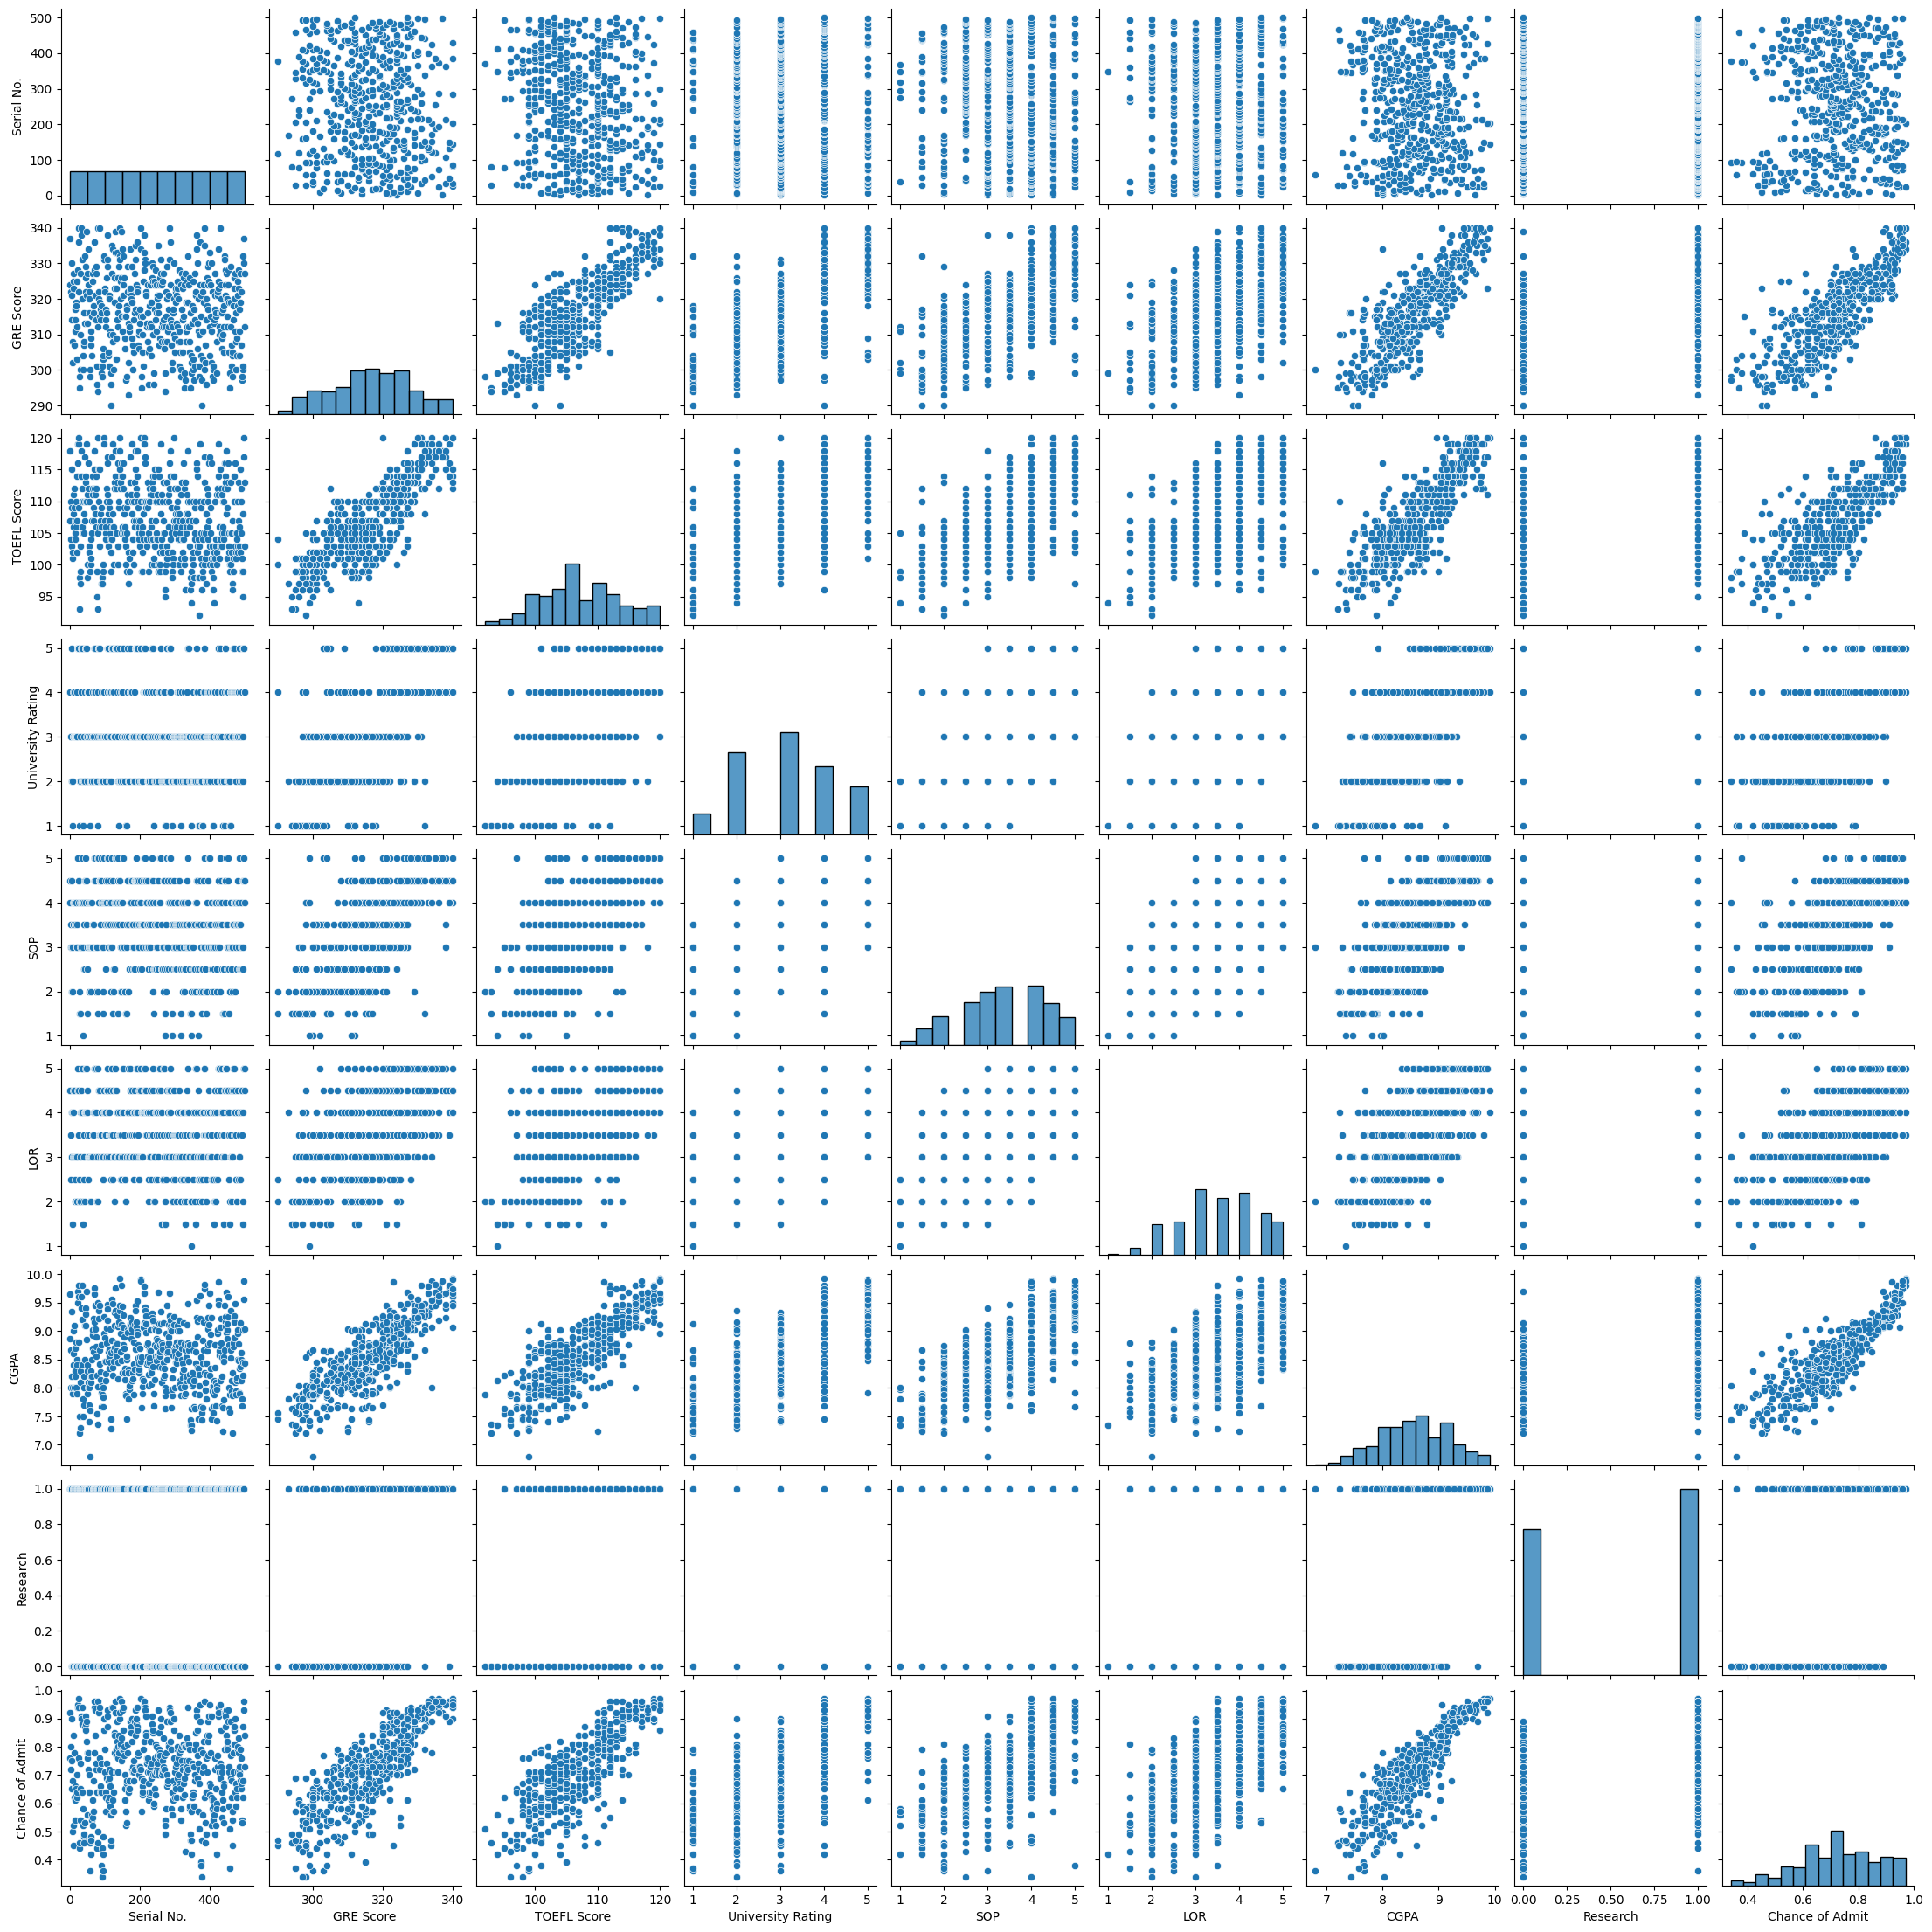

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(num_df)
plt.show()

# 14.Using the given dataset, calculate skewness of features and identify skewed variables.

In [77]:
import pandas as pd

df = pd.read_csv("/content/feature_engineering_dataset.csv")

print(df.head())

   id  age  fare  math_marks  science_marks
0   1   22   100          70             68
1   2   30   200          80             78
2   3   25   150          65             70
3   4   40   300          90             88
4   5   35   250          85             82


Select Numerical Columns

In [78]:
import numpy as np

num_df = df.select_dtypes(include=[np.number])

Calculate Skewness

In [79]:
skew_values = num_df.skew()

print("\nSkewness of Features:\n")
print(skew_values)


Skewness of Features:

id               0.000000
age              0.414770
fare             0.280924
math_marks      -0.479922
science_marks    0.136631
dtype: float64


Identify Skewed Variables

In [80]:
for col in skew_values.index:
    if skew_values[col] > 0:
        print(f"{col} → Positively skewed")
    elif skew_values[col] < 0:
        print(f"{col} → Negatively skewed")
    else:
        print(f"{col} → Symmetrical")

id → Symmetrical
age → Positively skewed
fare → Positively skewed
math_marks → Negatively skewed
science_marks → Positively skewed


# 15.Using the given dataset, implement a Logistic Regression model for binary classification.

In [87]:
import pandas as pd

df = pd.read_csv("/content/titanic_sample.csv")

print(df.head())
print(df.columns)

   survived  pclass     sex  age   fare embarked
0         0       3    male   22   7.25        S
1         1       1  female   38  71.28        C
2         1       3  female   26   7.92        S
3         1       1  female   35  53.10        S
4         0       3    male   35   8.05        S
Index(['survived', 'pclass', 'sex', 'age', 'fare', 'embarked'], dtype='object')


Prepare Features (X) and Target (y)

In [88]:
X = df.drop('survived', axis=1)   # Features
y = df['survived']               # Target             # Target (binary: 0 or 1)

Handle Categorical Data

In [89]:
X = pd.get_dummies(X, drop_first=True)

Split Dataset

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

Train Logistic Regression Model

In [91]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

Make Predictions

In [92]:
y_pred = model.predict(X_test)

print("Predicted Values:\n", y_pred)

Predicted Values:
 [0 1 0]
